In [1]:
print("hindi")

hindi


In [12]:
import math, random
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

**Variable**

In [13]:
# =========================
# Configuration
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMG_SIZE = 32
EMBED_DIM = 64

BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-4

TEMPERATURE = 0.07

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", device)

Device: cpu


**synthatic data**properties

In [14]:
colours = [
    'red',
    'green',
    'yellow',
    'purple',
    'orange',
    'pink',
    'brown',
    'gray'
]

shapes = [
    'square',
    'circle',
    'triangle'
]

positions = [
    'left',
    'centre',
    'right',
    'top',
    'bottom',
    'top-left',
    'top-right'
]

print("Colours:", colours)
print("Shapes:", shapes)
print("Positions:", positions)

Colours: ['red', 'green', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray']
Shapes: ['square', 'circle', 'triangle']
Positions: ['left', 'centre', 'right', 'top', 'bottom', 'top-left', 'top-right']


In [15]:
def draw_sample(
    colour,
    shape,
    position,
    img_size=IMG_SIZE
):

    # Create white image
    img = Image.new(
        'RGB',
        (img_size, img_size),
        'white'
    )

    draw = ImageDraw.Draw(img)

    margin = 5

    # Shape size
    shape_w = 12
    shape_h = 12

    # -------------------------
    # Calculate X coordinates
    # -------------------------

    if position == 'left':
        x0 = margin
        x1 = margin + shape_w

    elif position in ['top-left', 'bottom-left']:
        x0 = margin
        x1 = margin + shape_w

    elif position == 'right':
        x0 = img_size - margin - shape_w
        x1 = img_size - margin

    elif position in ['top-right', 'bottom-right']:
        x0 = img_size - margin - shape_w
        x1 = img_size - margin

    else:
        # Centre / top / bottom
        x0 = (img_size - shape_w) // 2
        x1 = x0 + shape_w


    # -------------------------
    # Calculate Y coordinates
    # -------------------------

    if position == 'top':
        y0 = margin
        y1 = margin + shape_h

    elif position in ['top-left', 'top-right']:
        y0 = margin
        y1 = margin + shape_h

    elif position == 'bottom':
        y0 = img_size - margin - shape_h
        y1 = img_size - margin

    elif position in ['bottom-left', 'bottom-right']:
        y0 = img_size - margin - shape_h
        y1 = img_size - margin

    else:
        # Centre / left / right
        y0 = (img_size - shape_h) // 2
        y1 = y0 + shape_h


    # -------------------------
    # Draw Shape
    # -------------------------

    if shape == 'square':

        draw.rectangle(
            [x0, y0, x1, y1],
            fill=colour,
            outline='black'
        )

    elif shape == 'circle':

        draw.ellipse(
            [x0, y0, x1, y1],
            fill=colour,
            outline='black'
        )

    elif shape == 'triangle':

        draw.polygon(
            [
                ((x0 + x1) // 2, y0),
                (x0, y1),
                (x1, y1)
            ],
            fill=colour,
            outline='black'
        )

    return img

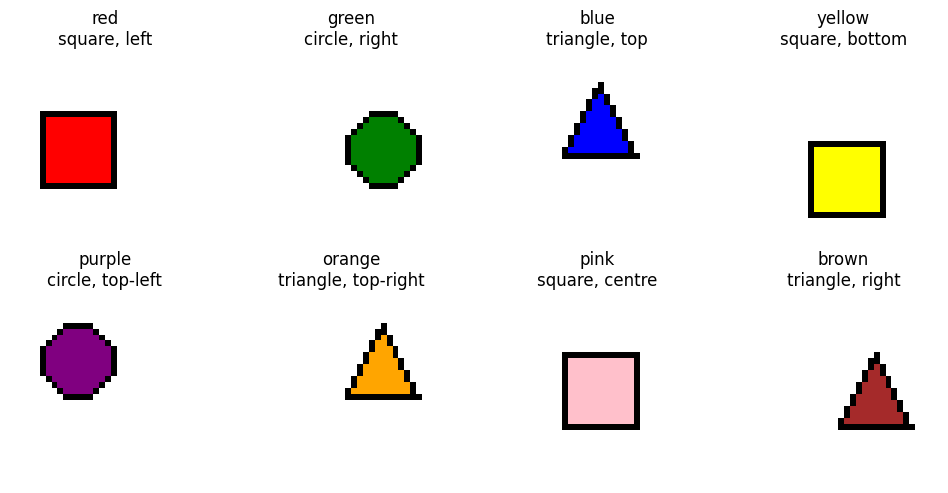

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

examples = [
    ('red', 'square', 'left'),
    ('green', 'circle', 'right'),
    ('blue', 'triangle', 'top'),
    ('yellow', 'square', 'bottom'),
    ('purple', 'circle', 'top-left'),
    ('orange', 'triangle', 'top-right'),
    ('pink', 'square', 'centre'),
    ('brown', 'triangle', 'right')
]

for ax, (colour, shape, position) in zip(
    axes.flat,
    examples
):

    img = draw_sample(
        colour,
        shape,
        position
    )

    ax.imshow(img)
    ax.set_title(
        f"{colour}\n{shape}, {position}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
def create_caption(colour, shape, position):

    if position == 'centre':
        position_text = 'in the centre'

    else:
        position_text = f'on the {position}'

    caption = (
        f"a {colour} {shape} "
        f"is {position_text}"
    )

    return caption

In [18]:
print(create_caption(
    'red',
    'square',
    'left'
))

print(create_caption(
    'green',
    'circle',
    'top-right'
))

a red square is on the left
a green circle is on the top-right


In [19]:
samples = []

for colour in colours:
    for shape in shapes:
        for position in positions:

            samples.append({
                'colour': colour,
                'shape': shape,
                'position': position
            })

print("Total combinations:", len(samples))

Total combinations: 168


In [20]:
special_tokens = [
    '<PAD>',
    '<UNK>'
]


all_captions = [
    create_caption(
        sample['colour'],
        sample['shape'],
        sample['position']
    )
    for sample in samples
]


vocab = {}

for token in special_tokens:
    vocab[token] = len(vocab)


for caption in all_captions:

    tokens = caption.lower().split()

    for token in tokens:

        if token not in vocab:
            vocab[token] = len(vocab)


PAD_TOKEN = vocab['<PAD>']
UNK_TOKEN = vocab['<UNK>']

print("Vocabulary size:", len(vocab))
print(vocab)

Vocabulary size: 25
{'<PAD>': 0, '<UNK>': 1, 'a': 2, 'red': 3, 'square': 4, 'is': 5, 'on': 6, 'the': 7, 'left': 8, 'in': 9, 'centre': 10, 'right': 11, 'top': 12, 'bottom': 13, 'top-left': 14, 'top-right': 15, 'circle': 16, 'triangle': 17, 'green': 18, 'yellow': 19, 'purple': 20, 'orange': 21, 'pink': 22, 'brown': 23, 'gray': 24}


In [21]:
MAX_TEXT_LEN = 10


def tokenize(text):

    tokens = text.lower().split()

    token_ids = []

    for token in tokens:

        token_ids.append(
            vocab.get(
                token,
                UNK_TOKEN
            )
        )

    # Padding
    if len(token_ids) < MAX_TEXT_LEN:

        token_ids += [
            PAD_TOKEN
        ] * (
            MAX_TEXT_LEN - len(token_ids)
        )

    else:

        token_ids = token_ids[
            :MAX_TEXT_LEN
        ]

    return torch.tensor(
        token_ids,
        dtype=torch.long
    )

In [22]:
caption = "a red square is on the left"

print(caption)
print(tokenize(caption))

a red square is on the left
tensor([2, 3, 4, 5, 6, 7, 8, 0, 0, 0])


In [23]:
class SyntheticVLDataset(Dataset):

    def __init__(self, samples):

        self.samples = samples

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        colour = sample['colour']
        shape = sample['shape']
        position = sample['position']

        # Image
        img = draw_sample(
            colour,
            shape,
            position
        )

        # Convert PIL → Tensor
        img = np.array(img)

        img = torch.tensor(
            img,
            dtype=torch.float32
        )

        # H,W,C → C,H,W
        img = img.permute(
            2, 0, 1
        )

        # Normalize 0-255 → 0-1
        img = img / 255.0

        # Text
        caption = create_caption(
            colour,
            shape,
            position
        )

        text = tokenize(caption)

        return img, text, caption

In [24]:
dataset = SyntheticVLDataset(
    samples
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Dataset size:", len(dataset))

Dataset size: 168


In [25]:
images, texts, captions = next(
    iter(dataloader)
)

print("Image shape:", images.shape)
print("Text shape:", texts.shape)
print("Example:", captions[0])

Image shape: torch.Size([32, 3, 32, 32])
Text shape: torch.Size([32, 10])
Example: a purple square is in the centre


Vision Encoder

In [26]:
class VisionEncoder(nn.Module):

    def __init__(
        self,
        embed_dim=EMBED_DIM
    ):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.fc = nn.Linear(
            128,
            embed_dim
        )

    def forward(self, x):

        x = self.encoder(x)

        x = x.flatten(1)

        x = self.fc(x)

        return x

In [27]:
class TextEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM,
        hidden_dim=128
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_dim,
            padding_idx=PAD_TOKEN
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(
            hidden_dim,
            embed_dim
        )

    def forward(self, x):

        # Token embeddings
        x = self.embedding(x)

        # Transformer
        x = self.transformer(x)

        # Mean pooling
        x = x.mean(dim=1)

        # Projection
        x = self.fc(x)

        return x

In [28]:
class ContrastiveVLM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM
    ):

        super().__init__()

        self.image_encoder = VisionEncoder(
            embed_dim
        )

        self.text_encoder = TextEncoder(
            vocab_size,
            embed_dim
        )

    def forward(
        self,
        images,
        texts
    ):

        image_features = (
            self.image_encoder(images)
        )

        text_features = (
            self.text_encoder(texts)
        )

        # L2 normalization
        image_features = F.normalize(
            image_features,
            dim=-1
        )

        text_features = F.normalize(
            text_features,
            dim=-1
        )

        return (
            image_features,
            text_features
        )

In [29]:
model = ContrastiveVLM(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM
).to(device)

print(model)

ContrastiveVLM(
  (image_encoder): VisionEncoder(
    (encoder): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (fc): Linear(in_features=128, out_features=64, bias=True)
  )
  (text_encoder): TextEncoder(
    (embedding): Embedding(25, 128, padding_idx=0)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
       

In [31]:
def contrastive_loss(
    image_features,
    text_features,
    temperature=TEMPERATURE
):

    # Similarity matrix
    logits = (
        image_features
        @ text_features.T
    ) / temperature

    batch_size = logits.size(0)

    labels = torch.arange(
        batch_size,
        device=logits.device
    )

    # Image → Text
    loss_i2t = F.cross_entropy(
        logits,
        labels
    )

    # Text → Image
    loss_t2i = F.cross_entropy(
        logits.T,
        labels
    )

    # Symmetric loss
    loss = (
        loss_i2t +
        loss_t2i
    ) / 2

    return loss, logits

In [32]:
# Move data to device
images = images.to(device)
texts = texts.to(device)

# Get image and text embeddings
image_features, text_features = model(
    images,
    texts
)

# Calculate contrastive loss
loss, logits = contrastive_loss(
    image_features,
    text_features
)

# Print output
print("Contrastive Loss:", loss.item())
print("Logits shape:", logits.shape)
print("Logits:")
print(logits)

Contrastive Loss: 3.588289260864258
Logits shape: torch.Size([32, 32])
Logits:
tensor([[-0.5370,  1.1543,  0.4539,  ...,  1.1845,  0.8596,  0.8677],
        [-0.5657,  1.1131,  0.4325,  ...,  1.1429,  0.8473,  0.8100],
        [-0.5989,  1.0672,  0.3905,  ...,  1.1071,  0.8032,  0.7716],
        ...,
        [-0.7475,  0.9925,  0.3950,  ...,  1.0531,  0.7318,  0.6907],
        [-0.6821,  1.0443,  0.4077,  ...,  1.1004,  0.7746,  0.7507],
        [-0.6086,  1.0620,  0.3951,  ...,  1.1208,  0.7928,  0.7745]],
       grad_fn=<DivBackward0>)


In [34]:
TEMPERATURE = 0.07

logits = (image_features @ text_features.T) / TEMPERATURE

In [35]:
def contrastive_loss(
    image_features,
    text_features,
    temperature=TEMPERATURE
):

    # Similarity matrix
    logits = (
        image_features @ text_features.T
    ) / temperature

    batch_size = logits.size(0)

    labels = torch.arange(
        batch_size,
        device=logits.device
    )

    # Image → Text
    loss_i2t = F.cross_entropy(
        logits,
        labels
    )

    # Text → Image
    loss_t2i = F.cross_entropy(
        logits.T,
        labels
    )

    # Symmetric loss
    loss = (
        loss_i2t + loss_t2i
    ) / 2

    return loss, logits

In [36]:
loss, logits = contrastive_loss(
    image_features,
    text_features
)

print("Loss:", loss.item())
print("Logits shape:", logits.shape)

Loss: 3.588289260864258
Logits shape: torch.Size([32, 32])


In [37]:
TEMPRATURE = 0.07

In [38]:
TEMPERATURE = 0.07

def contrastive_loss(
    image_features,
    text_features,
    temperature=TEMPERATURE
):

    # Image-Text similarity
    logits = (
        image_features @ text_features.T
    ) / temperature

    batch_size = logits.size(0)

    # Correct pair labels
    labels = torch.arange(
        batch_size,
        device=logits.device
    )

    # Image → Text
    loss_i2t = F.cross_entropy(
        logits,
        labels
    )

    # Text → Image
    loss_t2i = F.cross_entropy(
        logits.T,
        labels
    )

    # Symmetric contrastive loss
    loss = (
        loss_i2t + loss_t2i
    ) / 2

    return loss, logits

In [39]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [40]:
loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0

    for images, texts, captions in dataloader:

        # Move data to GPU/CPU
        images = images.to(device)
        texts = texts.to(device)

        # -------------------------
        # Forward pass
        # -------------------------

        image_features, text_features = model(
            images,
            texts
        )

        # -------------------------
        # Contrastive loss
        # -------------------------

        loss, logits = contrastive_loss(
            image_features,
            text_features
        )

        # -------------------------
        # Backpropagation
        # -------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    # Average loss
    avg_loss = total_loss / len(dataloader)

    loss_history.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/20] Loss: 3.3059
Epoch [2/20] Loss: 3.2271
Epoch [3/20] Loss: 3.2166
Epoch [4/20] Loss: 3.1865
Epoch [5/20] Loss: 3.0134
Epoch [6/20] Loss: 2.6703
Epoch [7/20] Loss: 2.4215
Epoch [8/20] Loss: 2.3062
Epoch [9/20] Loss: 2.0083
Epoch [10/20] Loss: 1.6089
Epoch [11/20] Loss: 1.6095
Epoch [12/20] Loss: 1.3621
Epoch [13/20] Loss: 1.2312
Epoch [14/20] Loss: 1.1869
Epoch [15/20] Loss: 1.0222
Epoch [16/20] Loss: 0.9824
Epoch [17/20] Loss: 0.9556
Epoch [18/20] Loss: 0.8776
Epoch [19/20] Loss: 0.8364
Epoch [20/20] Loss: 0.8032


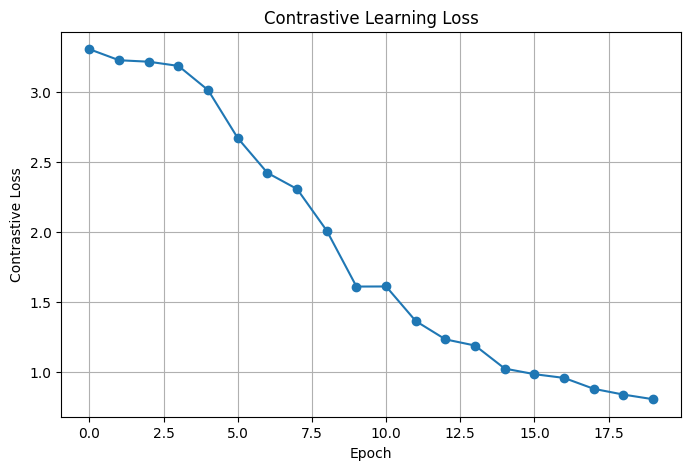

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Contrastive Learning Loss")

plt.grid(True)
plt.show()

In [42]:
model.eval()

all_image_features = []
all_text_features = []
all_captions = []

with torch.no_grad():

    for images, texts, captions in dataloader:

        images = images.to(device)
        texts = texts.to(device)

        image_features, text_features = model(
            images,
            texts
        )

        all_image_features.append(
            image_features.cpu()
        )

        all_text_features.append(
            text_features.cpu()
        )

        all_captions.extend(captions)


all_image_features = torch.cat(
    all_image_features
)

all_text_features = torch.cat(
    all_text_features
)

print(
    "Image features:",
    all_image_features.shape
)

print(
    "Text features:",
    all_text_features.shape
)

Image features: torch.Size([168, 64])
Text features: torch.Size([168, 64])


In [43]:
similarity = (
    all_image_features
    @ all_text_features.T
)

print("Similarity shape:", similarity.shape)

Similarity shape: torch.Size([168, 168])


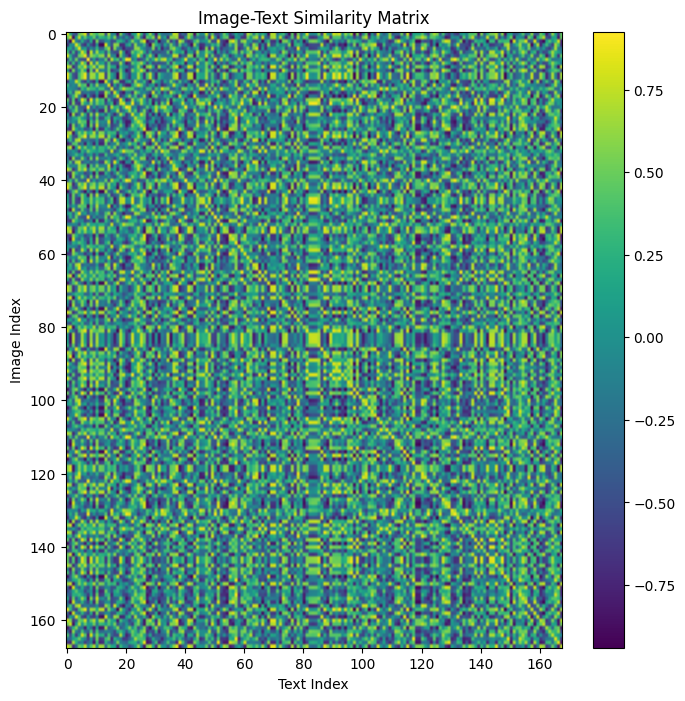

In [44]:
plt.figure(figsize=(8, 8))

plt.imshow(
    similarity.numpy(),
    aspect='auto'
)

plt.xlabel("Text Index")
plt.ylabel("Image Index")

plt.title(
    "Image-Text Similarity Matrix"
)

plt.colorbar()

plt.show()

In [45]:
def retrieve_caption(image_index, top_k=5):

    image_embedding = (
        all_image_features[image_index]
    )

    scores = (
        image_embedding
        @ all_text_features.T
    )

    top_scores, top_indices = torch.topk(
        scores,
        k=top_k
    )

    print(
        f"Image {image_index} - Top {top_k} captions:\n"
    )

    for rank, (score, idx) in enumerate(
        zip(top_scores, top_indices),
        start=1
    ):

        print(
            f"{rank}. "
            f"{all_captions[idx]} "
            f"(similarity={score.item():.4f})"
        )

In [46]:
retrieve_caption(
    image_index=10,
    top_k=5
)

Image 10 - Top 5 captions:

1. a brown triangle is on the left (similarity=0.8146)
2. a brown triangle is in the centre (similarity=0.7936)
3. a brown triangle is on the right (similarity=0.7793)
4. a brown triangle is on the top (similarity=0.7659)
5. a brown triangle is on the top-right (similarity=0.7603)


In [47]:
class VisionTokenEncoder(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        num_tokens=16
    ):
        super().__init__()

        self.num_tokens = num_tokens

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, embed_dim, 3, padding=1),
            nn.ReLU()
        )

        # 32x32 → 16x16 → 8x8
        # 8x8 = 64 tokens
        self.pool = nn.AdaptiveAvgPool2d(
            (4, 4)
        )

    def forward(self, x):

        x = self.conv(x)

        x = self.pool(x)

        # [B, C, H, W]
        # → [B, H*W, C]

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

In [48]:
class TextTokenEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_dim=64,
        num_heads=4,
        num_layers=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            hidden_dim,
            padding_idx=PAD_TOKEN
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

    def forward(self, x):

        x = self.embedding(x)

        x = self.transformer(x)

        return x

Cross attention layer

In [49]:
class CrossAttentionFusion(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4
    ):
        super().__init__()

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

        self.norm2 = nn.LayerNorm(
            embed_dim
        )

    def forward(
        self,
        text_tokens,
        image_tokens
    ):

        # Text = Query
        # Image = Key + Value

        attended_text, attention_weights = (
            self.cross_attention(
                query=text_tokens,
                key=image_tokens,
                value=image_tokens
            )
        )

        # Residual connection
        x = self.norm1(
            text_tokens + attended_text
        )

        # Feed Forward Network
        x = self.norm2(
            x + self.ffn(x)
        )

        return x, attention_weights

Complete Cross-Attention VLM

In [50]:
class CrossAttentionVLM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=64,
        num_heads=4
    ):
        super().__init__()

        self.vision_encoder = VisionTokenEncoder(
            embed_dim=embed_dim
        )

        self.text_encoder = TextTokenEncoder(
            vocab_size=vocab_size,
            hidden_dim=embed_dim,
            num_heads=num_heads
        )

        self.cross_attention = CrossAttentionFusion(
            embed_dim=embed_dim,
            num_heads=num_heads
        )

        self.image_projection = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.text_projection = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(
        self,
        images,
        texts
    ):

        # ---------------------
        # IMAGE
        # ---------------------

        image_tokens = self.vision_encoder(
            images
        )

        image_tokens = self.image_projection(
            image_tokens
        )

        # ---------------------
        # TEXT
        # ---------------------

        text_tokens = self.text_encoder(
            texts
        )

        # ---------------------
        # CROSS ATTENTION
        # ---------------------

        fused_text, attention_weights = (
            self.cross_attention(
                text_tokens,
                image_tokens
            )
        )

        # ---------------------
        # Pool
        # ---------------------

        fused_embedding = fused_text.mean(
            dim=1
        )

        fused_embedding = F.normalize(
            fused_embedding,
            dim=-1
        )

        return (
            fused_embedding,
            attention_weights
        )

In [51]:
cross_model = CrossAttentionVLM(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_heads=ATTENTION_HEADS
).to(device)

print(cross_model)

CrossAttentionVLM(
  (vision_encoder): VisionTokenEncoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
    )
    (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (text_encoder): TextTokenEncoder(
    (embedding): Embedding(25, 64, padding_idx=0)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_f

In [52]:
class TextGlobalEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=64
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_TOKEN
        )

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=2
        )

    def forward(self, x):

        x = self.embedding(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = F.normalize(
            x,
            dim=-1
        )

        return x

In [53]:
target_text_encoder = TextGlobalEncoder(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM
).to(device)

In [54]:
optimizer = torch.optim.AdamW(
    list(cross_model.parameters()) +
    list(target_text_encoder.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

In [55]:
def cross_attention_loss(
    fused_features,
    text_features,
    temperature=0.07
):

    logits = (
        fused_features @ text_features.T
    ) / temperature

    batch_size = logits.size(0)

    labels = torch.arange(
        batch_size,
        device=logits.device
    )

    loss_i2t = F.cross_entropy(
        logits,
        labels
    )

    loss_t2i = F.cross_entropy(
        logits.T,
        labels
    )

    loss = (
        loss_i2t + loss_t2i
    ) / 2

    return loss, logits

In [56]:
cross_loss_history = []

EPOCHS_CROSS = 20

for epoch in range(EPOCHS_CROSS):

    cross_model.train()
    target_text_encoder.train()

    total_loss = 0

    for images, texts, captions in dataloader:

        images = images.to(device)
        texts = texts.to(device)

        # ---------------------
        # Cross Attention Model
        # ---------------------

        fused_features, attention_weights = (
            cross_model(
                images,
                texts
            )
        )

        # ---------------------
        # Target text features
        # ---------------------

        text_features = target_text_encoder(
            texts
        )

        # ---------------------
        # Contrastive Loss
        # ---------------------

        loss, logits = cross_attention_loss(
            fused_features,
            text_features
        )

        # ---------------------
        # Backprop
        # ---------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss /
        len(dataloader)
    )

    cross_loss_history.append(
        avg_loss
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS_CROSS}] "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/20] Loss: 3.0528
Epoch [2/20] Loss: 1.5490
Epoch [3/20] Loss: 0.4674
Epoch [4/20] Loss: 0.2803
Epoch [5/20] Loss: 0.1285
Epoch [6/20] Loss: 0.0822
Epoch [7/20] Loss: 0.0811
Epoch [8/20] Loss: 0.0540
Epoch [9/20] Loss: 0.0502
Epoch [10/20] Loss: 0.0447
Epoch [11/20] Loss: 0.0482
Epoch [12/20] Loss: 0.0404
Epoch [13/20] Loss: 0.0327
Epoch [14/20] Loss: 0.0294
Epoch [15/20] Loss: 0.0292
Epoch [16/20] Loss: 0.0300
Epoch [17/20] Loss: 0.0280
Epoch [18/20] Loss: 0.0251
Epoch [19/20] Loss: 0.0259
Epoch [20/20] Loss: 0.0216


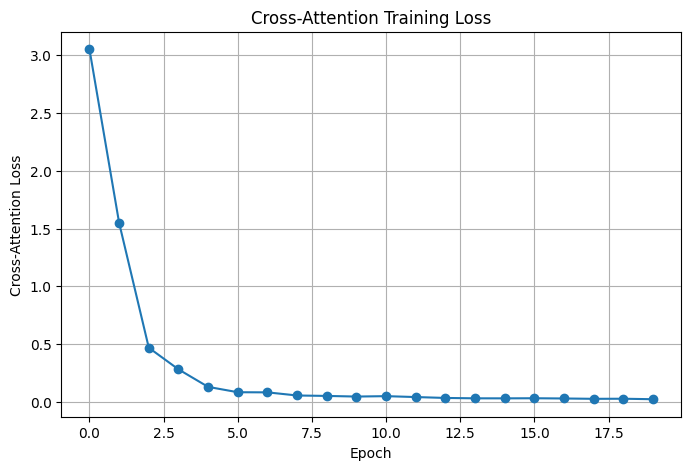

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    cross_loss_history,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Attention Loss")

plt.title(
    "Cross-Attention Training Loss"
)

plt.grid(True)

plt.show()

In [58]:
cross_model.eval()

images, texts, captions = next(
    iter(dataloader)
)

images = images.to(device)
texts = texts.to(device)

with torch.no_grad():

    fused_features, attention_weights = (
        cross_model(
            images,
            texts
        )
    )

print(
    "Attention shape:",
    attention_weights.shape
)

Attention shape: torch.Size([32, 10, 16])


In [59]:
sample_attention = attention_weights[0]

print(
    "Sample attention shape:",
    sample_attention.shape
)

Sample attention shape: torch.Size([10, 16])


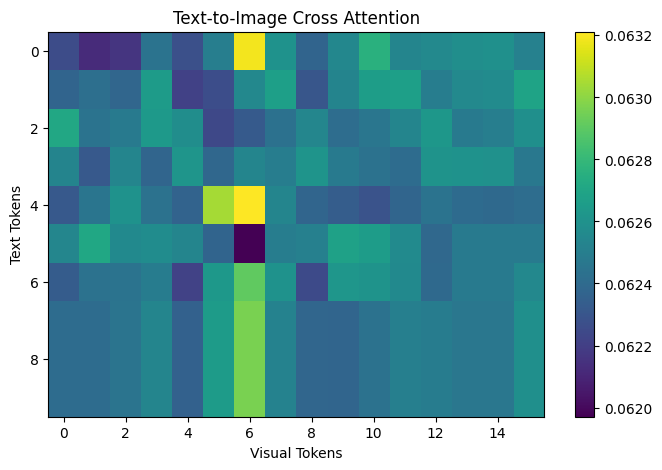

In [60]:
plt.figure(figsize=(8, 5))

plt.imshow(
    sample_attention.cpu().numpy(),
    aspect='auto'
)

plt.xlabel("Visual Tokens")
plt.ylabel("Text Tokens")

plt.title(
    "Text-to-Image Cross Attention"
)

plt.colorbar()

plt.show()